### Лабораторная работа №3. Работа с видеопотоком
Цель: Научится анализировать видео поток.

Целью лабораторной работы №3 является разработка системы анализа видеопотока для обнаружения и отслеживания перемещающегося объекта (в данном случае — лабораторной мыши) в реальном времени или на записанном видео. Основным подходом служит **вычитание фона** (background subtraction) — классический метод компьютерного зрения, позволяющий отделить движущиеся объекты от статичного фона без использования сложных нейросетевых моделей.

Метод основан на предположении, что фон в сцене остаётся относительно постоянным, а любые значимые изменения яркости вызваны движением объектов. Алгоритм состоит из трёх основных этапов: моделирование фона, выделение разницы и постобработка бинарного изображения.

### Моделирование статического фона

Для построения модели фона используется **медианный фильтр по времени** (temporal median background).  

Пусть имеется последовательность кадров $\{I_t(x,y)\}_{t=1}^N$. Для каждого пикселя $(x,y)$ значение фона $B(x,y)$ определяется как медиана всех значений в данном пикселе за весь видеоряд (или его подвыборку):

$$
B(x,y) = \text{median}\{I_1(x,y),\ I_2(x,y),\ \dots,\ I_N(x,y)\}
$$

Медианный подход обладает высокой устойчивостью к кратковременным выбросам (вспышкам, пролетающим объектам) и не требует параметрической модели распределения шума, в отличие от гауссовой модели фона.

### Вычитание фона и пороговая сегментация

На каждом новом кадре $I_t$ вычисляется абсолютная разница с моделью фона:

$$
D_t(x,y) = |I_t(x,y) - B(x,y)|
$$

Затем производится **пороговая бинаризация**:

$$
M_t(x,y) = 
\begin{cases}
255, & \text{если } D_t(x,y) > T \\
0,   & \text{иначе}
\end{cases}
$$

где $T$ — пороговое значение (в данной реализации $T = 18$). Полученная бинарная маска $M_t$ содержит области, где произошло значимое изменение яркости.

### Морфологическая постобработка

Для подавления мелкого шума и заполнения внутренних отверстий в объекте применяется **морфологическое закрытие** (closing):

$$
M_t' = (M_t \bullet K) = (M_t \oplus K) \ominus K
$$

где $K$ — структурирующий элемент (в реализации — квадрат $3\times3$), $\oplus$ — дилатация, $\ominus$ — эрозия. Операция закрытия соединяет близко расположенные компоненты и устраняет мелкие отверстия, сохраняя при этом форму крупного объекта.

### Выделение связных компонентов и выбор основного объекта

На очищенной маске $M_t'$ применяется алгоритм **Connected Component Labeling** (маркировка связных компонентов). Каждому связному множеству пикселей присваивается уникальный идентификатор.  

Для каждого компонента $C_i$ вычисляется площадь (количество пикселей). Выбирается компонент с максимальной площадью (largest blob), если его размер превышает минимальный порог $\text{min\_area} = 80$ пикселей. Это позволяет автоматически игнорировать мелкий шум и артефакты по краям кадра.

### Расчёт траектории движения

Для выбранного объекта вычисляется **центр масс** (centroid):

$$
c_x = \frac{1}{N} \sum_{(x,y) \in C} x, \quad
c_y = \frac{1}{N} \sum_{(x,y) \in C} y
$$

где $N$ — число пикселей в компоненте. Координаты $(c_x, c_y)$ сохраняются в последовательность и используются для построения траектории движения объекта.

### Дополнительные механизмы устойчивости

- **Warm-up период**: первые 30 кадров пропускаются для стабилизации фона.
- **Фильтр размера bounding box**: объект отбрасывается, если его ширина или высота превышает 60 % размера кадра (защита от ложных срабатываний).
- **Сохранение последнего центра**: при временной потере объекта (статичное положение) траектория продолжается по последнему известному центру.

### Заключение

Представленный алгоритм реализует классический конвейер обработки видео на основе вычитания фона, морфологической очистки и анализа связных компонентов. Метод не требует обучения, обладает низкой вычислительной сложностью и высокой интерпретируемостью, что делает его идеальным для учебных задач и систем реального времени. В ходе лабораторной работы были экспериментально подобраны оптимальные параметры ($T=18$, $\text{min\_area}=80$, ядро $3\times3$), обеспечивающие устойчивую детекцию и построение точной траектории объекта даже при его остановках.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_closing, label   # ← добавили label

video_path = 'mouse_1.avi'

cap = cv2.VideoCapture(video_path)

frames_for_median = []
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    if frame_idx % 5 == 0:
        frames_for_median.append(frame)
    frame_idx += 1

background = np.median(np.array(frames_for_median), axis=0).astype(np.uint8)
print(f"🤗 Медианный фон готов")
cap.release()

🤗 Медианный фон готов


In [2]:
cap = cv2.VideoCapture(video_path)

out = cv2.VideoWriter('output_with_trajectory.avi', 
                      cv2.VideoWriter_fourcc(*'XVID'), 
                      30, 
                      (int(cap.get(3)), int(cap.get(4))))

kernel = np.ones((3, 3), bool)
threshold = 18
min_area = 80

centers = []
frame_count = 0
last_center = None

print("🤗 Старт — warm-up + защита от большого блоба")


while True:
    ret, frame = cap.read()
    if not ret:
        break

    diff = cv2.absdiff(frame, background)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, binarized = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    cleaned = binary_closing(binarized, structure=kernel).astype(np.uint8) * 255

    labeled, num_labels = label(cleaned)
    if num_labels > 0:
        sizes = np.bincount(labeled.ravel())
        max_label = sizes[1:].argmax() + 1
        blob_size = sizes[max_label]

        if blob_size > min_area:
            y_coords, x_coords = np.nonzero(labeled == max_label)
            x1, x2 = int(np.min(x_coords)), int(np.max(x_coords))
            y1, y2 = int(np.min(y_coords)), int(np.max(y_coords))
            
            width = x2 - x1
            height = y2 - y1

            if width < 380 and height < 280:          # меньше 60%
                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2
                centers.append((cx, cy))
                last_center = (cx, cy)

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.circle(frame, (cx, cy), 10, (0, 0, 255), -1)
                cv2.putText(frame, f"#{len(centers)}", (x1, y1-15),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                print(f"😀 Кадр {frame_count} — МЫШКА! (размер {width}x{height}, blob={blob_size})")
            else:
                print(f"🫠 Кадр {frame_count} — слишком большой объект ({width}x{height})")
        else:
            print(f"🤔 Кадр {frame_count} — blob слишком маленький ({blob_size})")
    else:
        print(f"🫥 Кадр {frame_count} — ничего не найдено")

    # Рисуем последний центр, если мышка стоит
    if last_center is not None:
        cx, cy = last_center
        cv2.circle(frame, (cx, cy), 8, (0, 0, 255), -1)

    # Debug
    if frame_count % 30 == 0:
        debug = np.hstack([gray, cleaned])
        cv2.imwrite(f'debug/debug_bin_{frame_count:04d}.png', debug)

    out.write(frame)
    frame_count += 1

cap.release()
out.release()

print(f"\n🤗 ГОТОВО!")
print(f"   Кадров: {frame_count} | Точек в траектории: {len(centers)}")

🤗 Старт — warm-up + защита от большого блоба
🫠 Кадр 0 — слишком большой объект (637x477)
🫠 Кадр 1 — слишком большой объект (637x477)
🫠 Кадр 2 — слишком большой объект (637x477)
🫠 Кадр 3 — слишком большой объект (637x477)
🫠 Кадр 4 — слишком большой объект (637x477)
🫠 Кадр 5 — слишком большой объект (637x477)
🫠 Кадр 6 — слишком большой объект (637x477)
🫠 Кадр 7 — слишком большой объект (637x477)
🫠 Кадр 8 — слишком большой объект (637x477)
🫠 Кадр 9 — слишком большой объект (478x476)
😀 Кадр 10 — МЫШКА! (размер 115x175, blob=5951)
😀 Кадр 11 — МЫШКА! (размер 114x171, blob=5414)
😀 Кадр 12 — МЫШКА! (размер 114x169, blob=5060)
😀 Кадр 13 — МЫШКА! (размер 118x168, blob=4888)
😀 Кадр 14 — МЫШКА! (размер 118x169, blob=4898)
😀 Кадр 15 — МЫШКА! (размер 120x170, blob=4905)
😀 Кадр 16 — МЫШКА! (размер 114x168, blob=4811)
😀 Кадр 17 — МЫШКА! (размер 119x169, blob=4887)
😀 Кадр 18 — МЫШКА! (размер 119x168, blob=4882)
😀 Кадр 19 — МЫШКА! (размер 119x168, blob=4882)
😀 Кадр 20 — МЫШКА! (размер 118x169, blob=4854

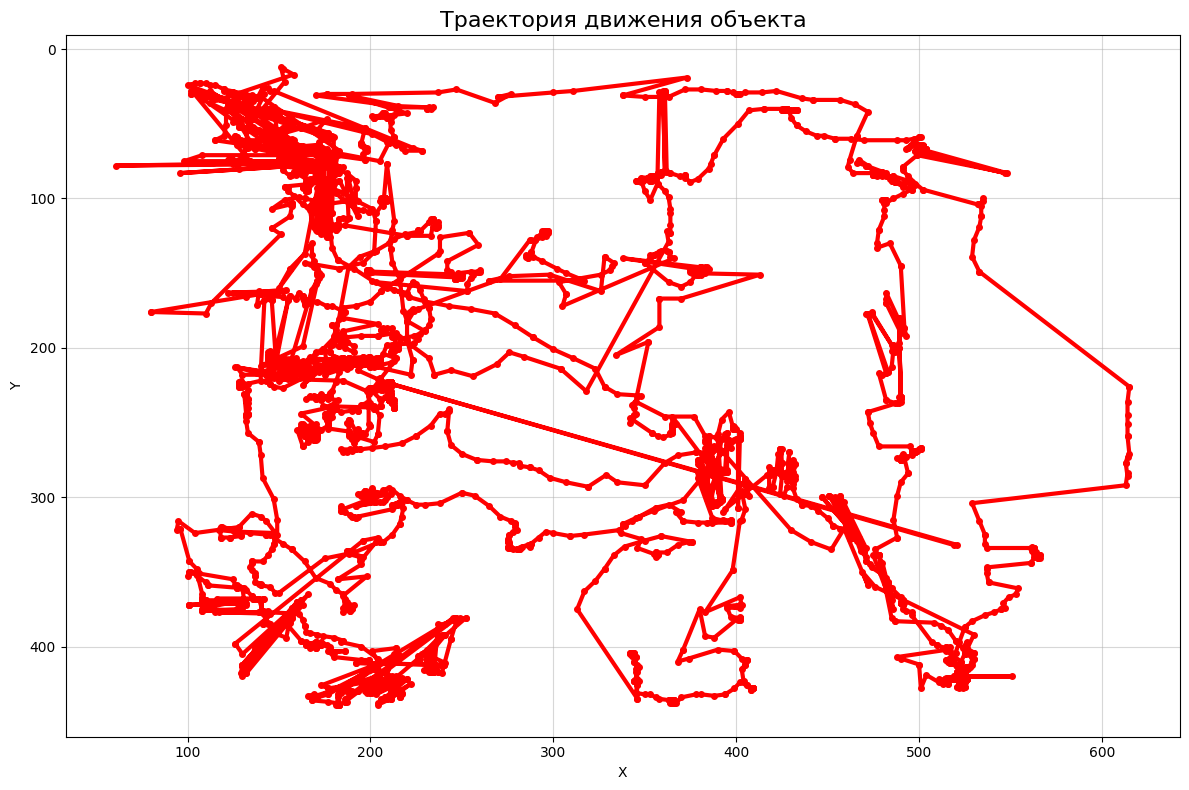

In [3]:
if len(centers) > 5:
    traj = np.array(centers)
    
    plt.figure(figsize=(12, 8))
    plt.plot(traj[:, 0], traj[:, 1], 'r-', linewidth=3, marker='o', markersize=4)
    plt.gca().invert_yaxis()
    plt.title('Траектория движения объекта', fontsize=16)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig('trajectory_lab3.png', dpi=300)
    plt.show()

In [4]:
print("🤗")

🤗
